# Decision Tree Regression Solution

## Objective

A vehicle manufacturer wants to understand the factors that influence the manufacturer suggested retail price (MSRP) of vehicles. The dataset contains vehicle specifications such as engine characteristics, transmission type, fuel type, mileage, and vehicle dimensions. The objective is to prepare the data, build a decision tree Regression model to predict vehicle prices, evaluate its performance using MSE and RMSE, and identify the most important features.

## **Task 1**
*Import the libraries required for data preparation, modelling, evaluation, and visualisation.*

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import warnings;warnings.filterwarnings('ignore')

# Data Preparation


## **Task 2**

- *Load the dataset and inspect its shape and  print few rows*
- *Check data types and column names*
- *Check for missing values and duplicates*

In [2]:
df = pd.read_csv('Vehicle_Price_Prediction.csv'); df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11199 entries, 0 to 11198
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11199 non-null  object 
 1   Model              11199 non-null  object 
 2   Year               11199 non-null  int64  
 3   Engine Fuel Type   11199 non-null  object 
 4   Engine HP          11199 non-null  float64
 5   Engine Cylinders   11199 non-null  float64
 6   Transmission Type  11199 non-null  object 
 7   Driven_Wheels      11199 non-null  object 
 8   Number of Doors    11199 non-null  float64
 9   Market Category    11199 non-null  object 
 10  Vehicle Size       11199 non-null  object 
 11  Vehicle Style      11199 non-null  object 
 12  highway MPG        11199 non-null  int64  
 13  city mpg           11199 non-null  int64  
 14  Popularity         11199 non-null  int64  
 15  MSRP               11199 non-null  int64  
dtypes: float64(3), int64(5

In [4]:
print('Missing values in each column:'); print(df.isnull().sum())
duplicate_count = df.duplicated().sum(); print('\nTotal duplicate records:', duplicate_count)

Missing values in each column:
Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

Total duplicate records: 0


## **Task 3**
*Separate the predictor variables and the target variable.*

In [5]:
X = df.drop('MSRP', axis = 1);y = df['MSRP']
print('Feature dataset shape:', X.shape);print('Target dataset shape:', y.shape)

Feature dataset shape: (11199, 15)
Target dataset shape: (11199,)


## **Task 4** 
*Split the feature and target datasets into training and testing sets.*

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.40, random_state = 42)
print('Training feature shape:', X_train.shape);print('Testing feature shape:', X_test.shape)

Training feature shape: (6719, 15)
Testing feature shape: (4480, 15)


## **Task 5**
*Apply multi-hot encoding to the Market Category column in the training and testing data*

In [7]:
train_market_encoded = X_train['Market Category'].str.get_dummies(sep = ',')
train_market_encoded.columns = (train_market_encoded.columns.str.strip())
train_market_encoded = train_market_encoded.add_prefix('Market Category_')

In [8]:
test_market_encoded = X_test['Market Category'].str.get_dummies(sep = ',')
test_market_encoded.columns = (test_market_encoded.columns.str.strip())
test_market_encoded = test_market_encoded.add_prefix('Market Category_')
test_market_encoded = test_market_encoded.reindex(columns = train_market_encoded.columns,fill_value = 0)

In [9]:
X_train = X_train.drop(columns = 'Market Category')
X_test = X_test.drop(columns = 'Market Category')
X_train = pd.concat([X_train, train_market_encoded], axis = 1)
X_test = pd.concat([X_test, test_market_encoded], axis = 1)

## **Task 6**
*Convert the remaining categorical features into one-hot encoded columns.*

In [10]:
categorical_columns = X_train.select_dtypes(include = 'object').columns;print(categorical_columns)

Index(['Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
       'Driven_Wheels', 'Vehicle Size', 'Vehicle Style'],
      dtype='object')


In [11]:
encoder = OneHotEncoder(handle_unknown = 'ignore', drop = 'first', sparse_output = False)
train_encoded_values = encoder.fit_transform(X_train[categorical_columns])
test_encoded_values = encoder.transform( X_test[categorical_columns])
encoded_column_names = encoder.get_feature_names_out(categorical_columns)
train_encoded_df = pd.DataFrame(train_encoded_values, columns = encoded_column_names, index = X_train.index)
test_encoded_df = pd.DataFrame( test_encoded_values, columns = encoded_column_names, index = X_test.index)

In [12]:
X_train = X_train.drop(columns = categorical_columns)
X_test = X_test.drop(columns = categorical_columns)
X_train = pd.concat([X_train, train_encoded_df], axis = 1)
X_test = pd.concat([X_test, test_encoded_df], axis = 1)

# Model Training


## **Task 7**
*Train a baseline decision tree regressor*

In [13]:
dt_reg = DecisionTreeRegressor(criterion = 'squared_error', random_state = 42); dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

## **Task 8**
*Display the depth and number of leaves of the baseline decision tree model. Also find the average number of samples per leaf node.*

In [14]:
print('Baseline tree depth:', dt_reg.get_depth()); print('Baseline number of leaves:', dt_reg.get_n_leaves())

Baseline tree depth: 38
Baseline number of leaves: 4211


In [15]:
print('Average number of samples per leaf:', len(X_train) /dt_reg.get_n_leaves())

Average number of samples per leaf: 1.5955829969128472


## **Task 9**
*Visualise the first three levels of the fitted baseline decision tree.*

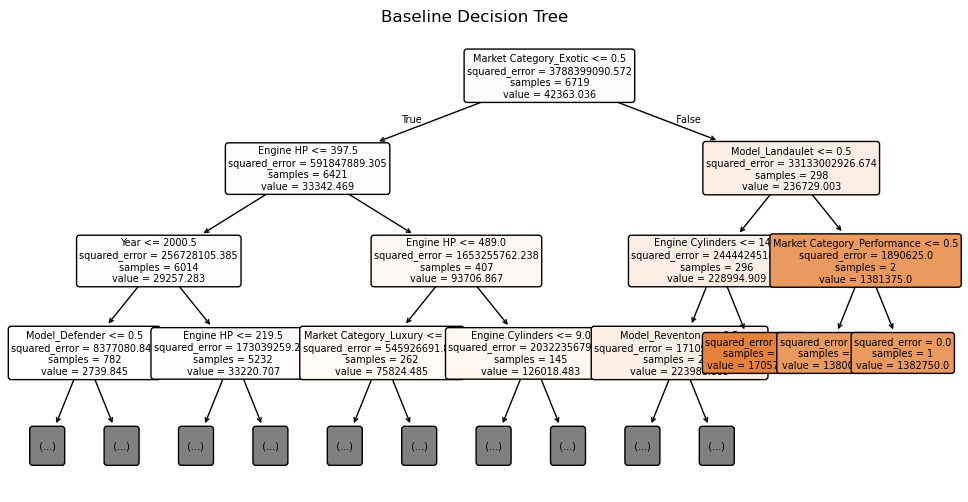

In [16]:
plt.figure(figsize = (12, 6))
plot_tree(dt_reg, feature_names = X_train.columns, filled = True, rounded = True, max_depth = 3, fontsize = 7)
plt.title('Baseline Decision Tree')
plt.show()

## **Task 10**

*Generate predictions for the training and testing datasets.*

In [17]:
train_pred = dt_reg.predict(X_train); test_pred = dt_reg.predict(X_test)

## **Task 11**
*Plot the actual and predicted MSRP values as scatterplots for the training and testing datasets.*

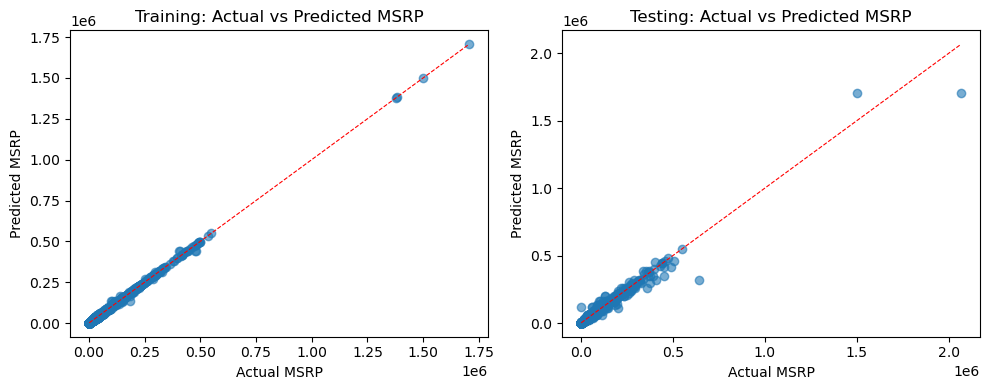

In [18]:
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha = 0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color = 'red', linestyle = '--', linewidth = 0.8)
plt.xlabel('Actual MSRP'); plt.ylabel('Predicted MSRP'); plt.title('Training: Actual vs Predicted MSRP')
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--', linewidth = 0.8)
plt.xlabel('Actual MSRP'); plt.ylabel('Predicted MSRP'); plt.title('Testing: Actual vs Predicted MSRP')
plt.tight_layout()
plt.show()

# Model Interpretation

## **Task 12**
*Evaluate the baseline model using MSE and RMSE for the training and testing datasets.*

In [19]:
train_mse = mean_squared_error(y_train, train_pred); test_mse = mean_squared_error(y_test, test_pred)
train_rmse = np.sqrt(train_mse); test_rmse = np.sqrt(test_mse)
print('Training MSE:', round(train_mse, 2)); print('Testing MSE:', round(test_mse, 2))
print('Training RMSE:', round(train_rmse, 2)); print('Testing RMSE:', round(test_rmse, 2))

Training MSE: 5556300.34
Testing MSE: 111955330.7
Training RMSE: 2357.18
Testing RMSE: 10580.89


## **Task 13**
*Identify and visualise the top five influential features used by the baseline model.*

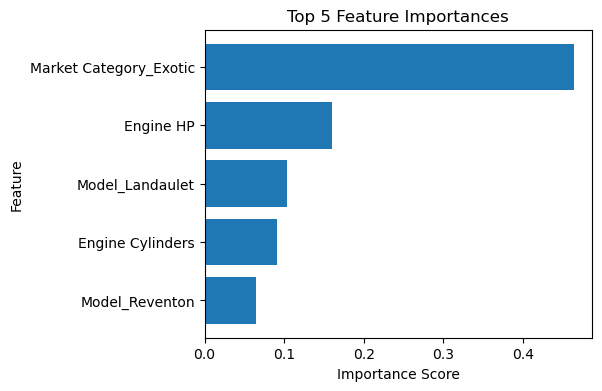

In [20]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': dt_reg.feature_importances_}).sort_values('Importance', ascending = False)
top = feature_importance.head(5)
plt.figure(figsize = (5, 4))
plt.barh(top['Feature'], top['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score'); plt.ylabel('Feature'); plt.title('Top 5 Feature Importances')
plt.show()

# Hyperparameter Tuning


## **Task 14**
*Tune the decision tree regressor on its maximum depth using grid search cross-validation, select the best model, and train it using the training data.*

In [21]:
param_grid = {'max_depth': [30, 35, 40]}
grid = GridSearchCV(DecisionTreeRegressor(criterion = 'squared_error', random_state = 42),
                    param_grid, cv = 5, verbose = 10, scoring = 'neg_root_mean_squared_error')
grid.fit(X_train, y_train)
print('Best hyperparameters:', grid.best_params_); print('Best cross-validation RMSE:', round(-grid.best_score_, 2))

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5; 1/3] START max_depth=30................................................
[CV 1/5; 1/3] END .............max_depth=30;, score=-9229.589 total time=   0.1s
[CV 2/5; 1/3] START max_depth=30................................................
[CV 2/5; 1/3] END ............max_depth=30;, score=-39630.704 total time=   0.1s
[CV 3/5; 1/3] START max_depth=30................................................
[CV 3/5; 1/3] END .............max_depth=30;, score=-7861.157 total time=   0.1s
[CV 4/5; 1/3] START max_depth=30................................................
[CV 4/5; 1/3] END .............max_depth=30;, score=-8051.564 total time=   0.2s
[CV 5/5; 1/3] START max_depth=30................................................
[CV 5/5; 1/3] END ............max_depth=30;, score=-33760.876 total time=   0.3s
[CV 1/5; 2/3] START max_depth=35................................................
[CV 1/5; 2/3] END .............max_depth=35;, sco

In [22]:
best_tree = grid.best_estimator_; best_tree.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=35, random_state=42)

## **Task 15**
*Generate predictions using the optimised tree and plot the actual and predicted MSRP values as scatterplots for the training and testing datasets.*

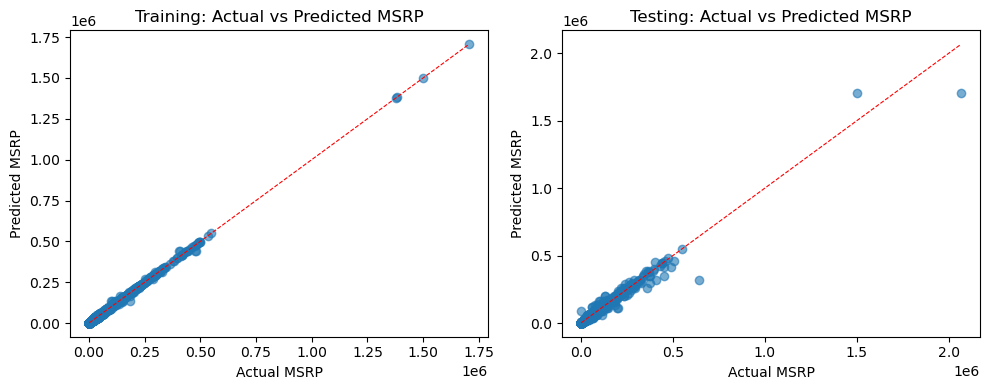

In [23]:
train_pred = best_tree.predict(X_train); test_pred = best_tree.predict(X_test)
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha = 0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color = 'red', linestyle = '--', linewidth = 0.8)
plt.xlabel('Actual MSRP'); plt.ylabel('Predicted MSRP'); plt.title('Training: Actual vs Predicted MSRP')
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--', linewidth = 0.8)
plt.xlabel('Actual MSRP'); plt.ylabel('Predicted MSRP'); plt.title('Testing: Actual vs Predicted MSRP')
plt.tight_layout()
plt.show()

## **Task 16**
*Visualise the first three levels of the fitted optimised decision tree.*

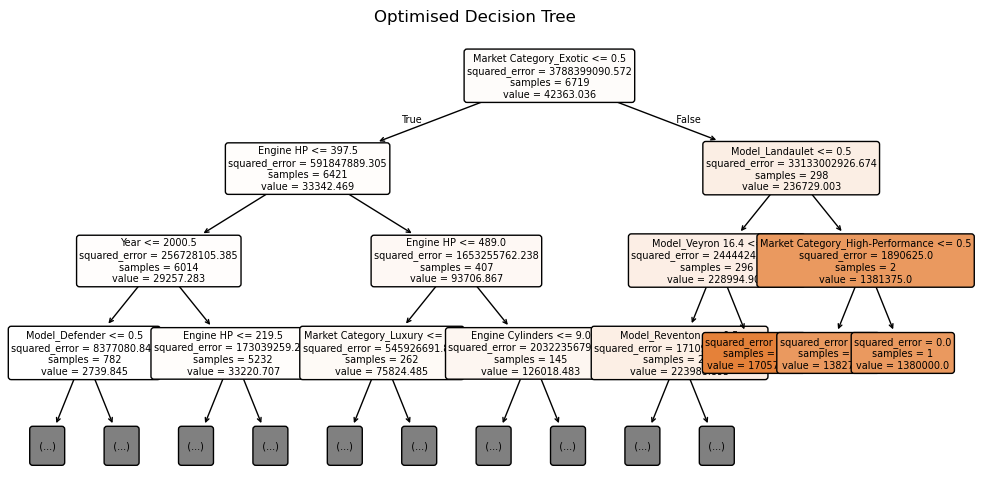

In [24]:
plt.figure(figsize = (12, 6))
plot_tree(best_tree, feature_names = X_train.columns, filled = True, rounded = True, max_depth = 3, fontsize = 7)
plt.title('Optimised Decision Tree')
plt.show()

## **Task 17**
*Tune the decision tree regressor with other parameters, display the best results, and train the selected model using the training data.*

In [25]:
s_param_grid = {'max_depth': range(35, 42), 'min_samples_split': range(2, 7), 'min_samples_leaf': range(1, 4)}
s_grid = GridSearchCV(estimator = DecisionTreeRegressor(random_state = 42), param_grid = s_param_grid,
                      scoring = 'neg_root_mean_squared_error', cv = 5, verbose = 10)
s_grid.fit(X_train, y_train)
print('Best hyperparameters:', s_grid.best_params_); print('Best cross-validation RMSE:', round(-s_grid.best_score_, 2))

Fitting 5 folds for each of 105 candidates, totalling 525 fits
[CV 1/5; 1/105] START max_depth=35, min_samples_leaf=1, min_samples_split=2.....
[CV 1/5; 1/105] END max_depth=35, min_samples_leaf=1, min_samples_split=2;, score=-8985.511 total time=   0.2s
[CV 2/5; 1/105] START max_depth=35, min_samples_leaf=1, min_samples_split=2.....
[CV 2/5; 1/105] END max_depth=35, min_samples_leaf=1, min_samples_split=2;, score=-38450.787 total time=   0.1s
[CV 3/5; 1/105] START max_depth=35, min_samples_leaf=1, min_samples_split=2.....
[CV 3/5; 1/105] END max_depth=35, min_samples_leaf=1, min_samples_split=2;, score=-8135.139 total time=   0.1s
[CV 4/5; 1/105] START max_depth=35, min_samples_leaf=1, min_samples_split=2.....
[CV 4/5; 1/105] END max_depth=35, min_samples_leaf=1, min_samples_split=2;, score=-7753.005 total time=   0.2s
[CV 5/5; 1/105] START max_depth=35, min_samples_leaf=1, min_samples_split=2.....
[CV 5/5; 1/105] END max_depth=35, min_samples_leaf=1, min_samples_split=2;, score=-3371

In [26]:
s_best_tree = s_grid.best_estimator_; s_best_tree.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=37, min_samples_split=3, random_state=42)

## **Task 18** ##
- *Generate predictions using the second optimised decision tree model.* 
- *Plot the actual and predicted MSRP values for the training and testing data.*

In [27]:
s_train_pred = s_best_tree.predict(X_train); s_test_pred = s_best_tree.predict(X_test)

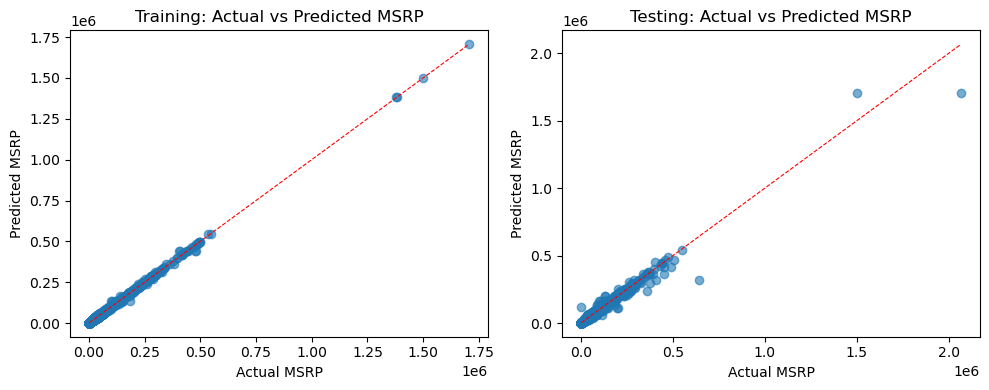

In [28]:
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_train, s_train_pred, alpha = 0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color = 'red', linestyle = '--', linewidth = 0.8)
plt.xlabel('Actual MSRP'); plt.ylabel('Predicted MSRP'); plt.title('Training: Actual vs Predicted MSRP')
plt.subplot(1, 2, 2)
plt.scatter(y_test, s_test_pred, alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '--', linewidth = 0.8)
plt.xlabel('Actual MSRP'); plt.ylabel('Predicted MSRP'); plt.title('Testing: Actual vs Predicted MSRP')
plt.tight_layout()
plt.show()

## **Task 19** ##
- *Evaluate the second optimised decision tree model using training and testing MSE and RMSE.*
- *Visualise the first three levels of the second optimised decision tree model.*

In [29]:
s_train_mse = mean_squared_error(y_train, s_train_pred); s_test_mse = mean_squared_error(y_test, s_test_pred)
s_train_rmse = np.sqrt(s_train_mse); s_test_rmse = np.sqrt(s_test_mse)
print('Second tuned training MSE:', round(s_train_mse, 2)); print('Second tuned testing MSE:', round(s_test_mse, 2))
print('Second tuned training RMSE:', round(s_train_rmse, 2)); print('Second tuned testing RMSE:', round(s_test_rmse, 2))

Second tuned training MSE: 6229087.18
Second tuned testing MSE: 110625314.52
Second tuned training RMSE: 2495.81
Second tuned testing RMSE: 10517.86


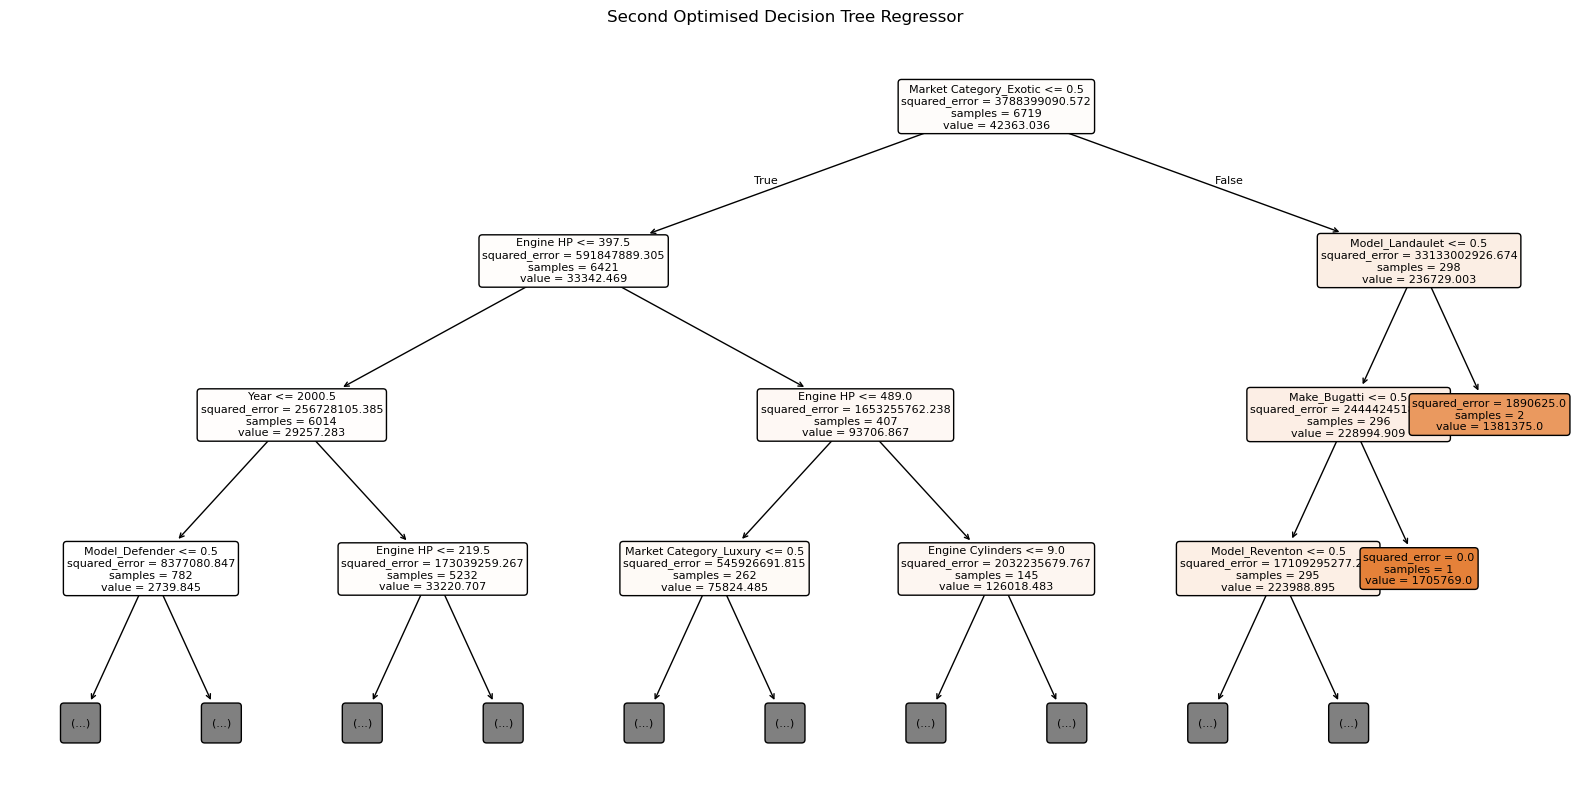

In [30]:
plt.figure(figsize = (20, 10))
plot_tree(s_best_tree, feature_names = X_train.columns, filled = True, rounded = True, max_depth = 3, fontsize = 8)
plt.title('Second Optimised Decision Tree Regressor')
plt.show()

# Model Comparison


## **Task 20**
*Compare the MSE and RMSE values of the default, optimised, and second optimised decision tree models.*

In [31]:
train_best_mse = mean_squared_error(y_train, train_pred); test_best_mse = mean_squared_error(y_test, test_pred)
train_best_rmse = np.sqrt(train_best_mse); test_best_rmse = np.sqrt(test_best_mse)
comparison = pd.DataFrame({'Metric': ['Training MSE', 'Testing MSE', 'Training RMSE', 'Testing RMSE'],
                           'Default': [train_mse, test_mse, train_rmse, test_rmse],
                           'Single_Hyperparameter': [train_best_mse, test_best_mse, train_best_rmse, test_best_rmse],
                           'Multiple_Hyperparameters': [s_train_mse, s_test_mse, s_train_rmse, s_test_rmse]})
comparison.set_index('Metric').round(0).astype(int)

,Default,Single_Hyperparameter,Multiple_Hyperparameters
Metric,,,
Training MSE,5556300,5556337,6229087
Testing MSE,111955331,112693713,110625315
Training RMSE,2357,2357,2496
Testing RMSE,10581,10616,10518
